# Cybersecurity Benchmark

This notebook imports saved cybersecurity runs from `results/cybersecurity`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    discrete_transport_tv_bound_table,
    load_runs,
    objective_table,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)

ENV = 'cybersecurity'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 30 saved runs from /home/adonis/Internship/mfc/results/cybersecurity


## Validation Reward

Mean validation reward over training, with one standard deviation across the five seeds. This compares REINFORCE, MF-REINFORCE, and transport for each perturbation level.

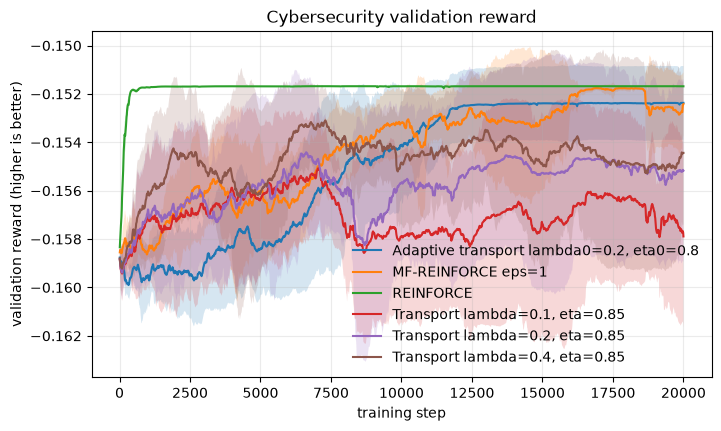

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=3, flow='exact', ax=ax)
    ax.set_title('Cybersecurity validation reward')
    plt.show()

## Learned State Distribution Flow

State-probability trajectories under the best saved policy for each algorithm and perturbation. The four curves correspond to DI, DS, UI, and US.

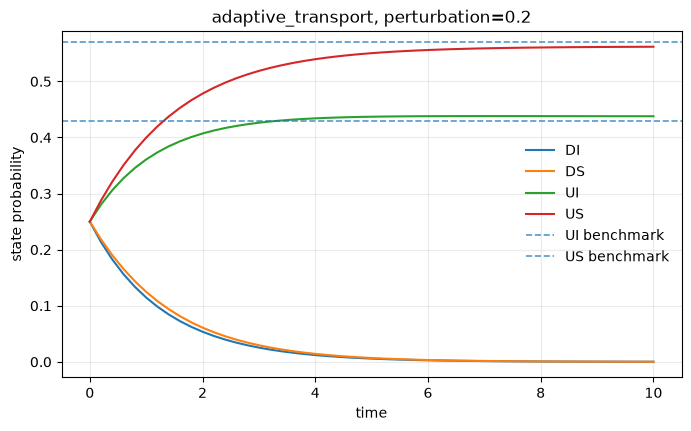

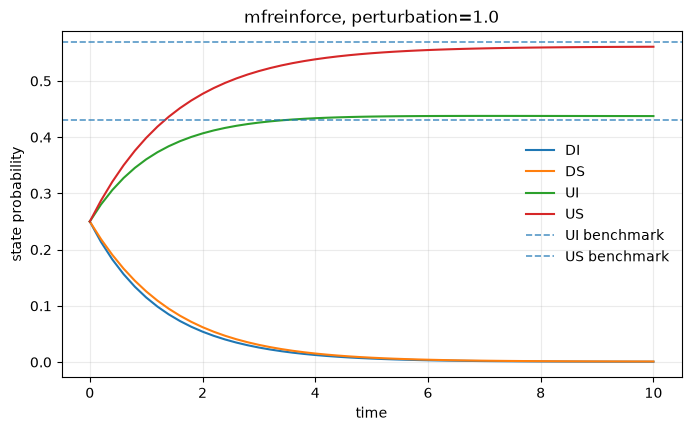

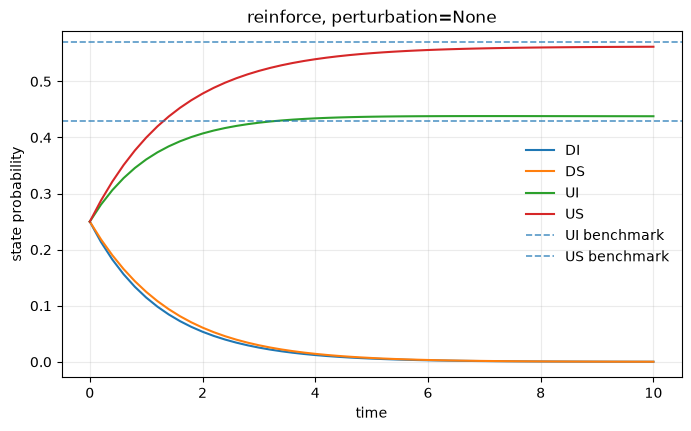

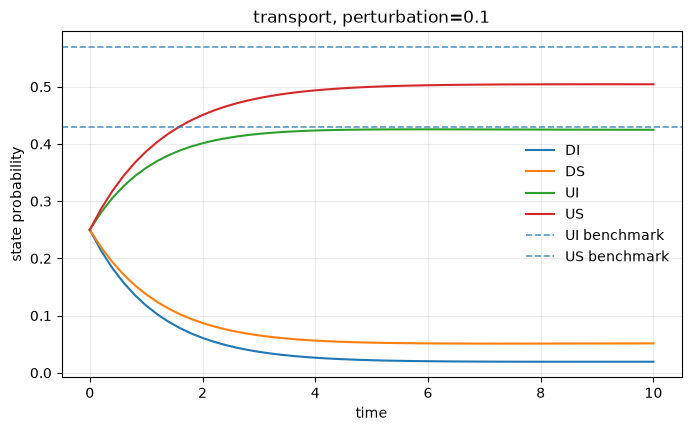

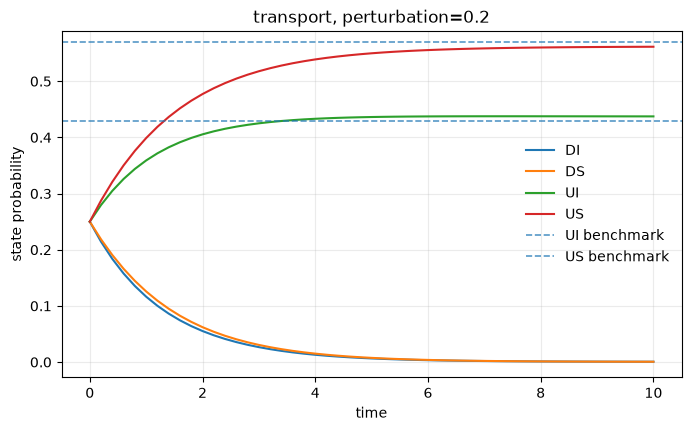

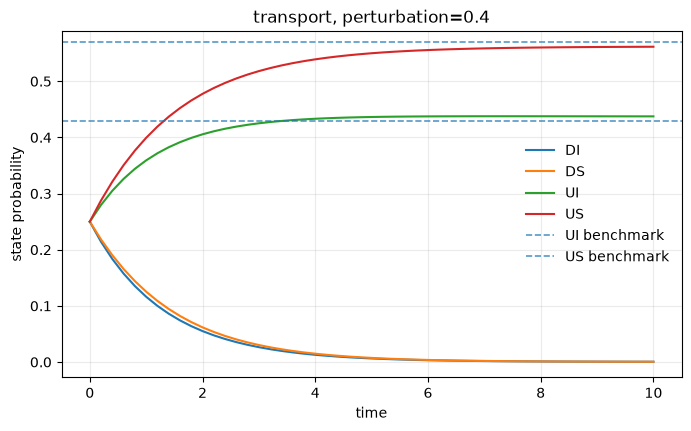

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Transport Perturbation Bound

For simplex transport, the total-variation distance between the perturbed population law and the unperturbed law is bounded by the selected perturbation level.

In [4]:
tv_bounds = discrete_transport_tv_bound_table(runs)
display(tv_bounds if not tv_bounds.empty else pd.DataFrame({'message': ['No transport runs found yet.']}))

,env,label,flow,horizon,seed,lambda,eta,max_tv_upper_bound,satisfies_lambda_bound
0,cybersecurity,"Transport lambda=0.1, eta=0.85",exact,3,0,0.1,0.85,0.077235,True
1,cybersecurity,"Transport lambda=0.1, eta=0.85",exact,3,1,0.1,0.85,0.078955,True
2,cybersecurity,"Transport lambda=0.1, eta=0.85",exact,3,2,0.1,0.85,0.081107,True
3,cybersecurity,"Transport lambda=0.1, eta=0.85",exact,3,3,0.1,0.85,0.077001,True
4,cybersecurity,"Transport lambda=0.1, eta=0.85",exact,3,4,0.1,0.85,0.084257,True
5,cybersecurity,"Transport lambda=0.2, eta=0.85",exact,3,0,0.2,0.85,0.164047,True
6,cybersecurity,"Transport lambda=0.2, eta=0.85",exact,3,1,0.2,0.85,0.166317,True
7,cybersecurity,"Transport lambda=0.2, eta=0.85",exact,3,2,0.2,0.85,0.151608,True
8,cybersecurity,"Transport lambda=0.2, eta=0.85",exact,3,3,0.2,0.85,0.154305,True
9,cybersecurity,"Transport lambda=0.2, eta=0.85",exact,3,4,0.2,0.85,0.168470,True


## Objective and Runtime Tables

Final validation rewards, estimated simulator budgets, and average runtime per algorithm configuration.

display(objective_table(runs))
display(runtime_table(runs))